In [63]:
import pandas as pd

In [64]:
def load_data(file_path):
    """Load data from a CSV file into a pandas DataFrame."""
    return pd.read_csv(file_path)

In [65]:
df = load_data('credit_card_transactions.csv')

In [66]:
df.head()

,IP Address,User ID,Account Number,Age,Shipping Address,Transaction Date,Transaction Time,Transaction Value,Product Category,Units Purchased
0,3.56.123.0,johnp,25671147,32.0,"1542, Orchid Lane, WA 98706, US",15-5-20,15:00:05,$121.58,Clothing,1
1,3.56.123.0,johnp,25671147,32.0,"1542, Orchid Lane, WA 98706, US",10-6-20,10:23:10,$79.23,Electronics,2
2,3.56.123.0,johnp,25671147,32.0,"1542, Orchid Lane, WA 98706, US",1-6-20,07:12:45,NaN,Home Décor,1
3,1.186.52.7,johnp,25671147,32.0,In-store,3-6-20,01:11:10,"$2,009.99",Electronics,10
4,NaN,johnp,25671147,32.0,In-store,2020-06-03,01:15:12,"$4,131.00",Electronics,15


### Cleanning and transform

The transaction date has differents formats

In [67]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], dayfirst=True, errors='coerce')

df['Transaction Date'] = df['Transaction Date'].dt.strftime('%d-%m-%Y')

C:\Users\Hp\AppData\Local\Temp\ipykernel_25588\3603607700.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], dayfirst=True, errors='coerce')


The transaction time format

In [68]:
df['Hour'] = pd.to_datetime(df['Transaction Time'], format='%H:%M:%S').dt.hour

In [69]:
df.head()

,IP Address,User ID,Account Number,Age,Shipping Address,Transaction Date,Transaction Time,Transaction Value,Product Category,Units Purchased,Hour
0,3.56.123.0,johnp,25671147,32.0,"1542, Orchid Lane, WA 98706, US",15-05-2020,15:00:05,$121.58,Clothing,1,15
1,3.56.123.0,johnp,25671147,32.0,"1542, Orchid Lane, WA 98706, US",10-06-2020,10:23:10,$79.23,Electronics,2,10
2,3.56.123.0,johnp,25671147,32.0,"1542, Orchid Lane, WA 98706, US",01-06-2020,07:12:45,NaN,Home Décor,1,7
3,1.186.52.7,johnp,25671147,32.0,In-store,03-06-2020,01:11:10,"$2,009.99",Electronics,10,1
4,NaN,johnp,25671147,32.0,In-store,03-06-2020,01:15:12,"$4,131.00",Electronics,15,1


Looking for NULLS 

In [70]:
filas_incompletas = df[df.isnull().any(axis=1)]
display(filas_incompletas)

,IP Address,User ID,Account Number,Age,Shipping Address,Transaction Date,Transaction Time,Transaction Value,Product Category,Units Purchased,Hour
2,3.56.123.0,johnp,25671147,32.0,"1542, Orchid Lane, WA 98706, US",01-06-2020,07:12:45,NaN,Home Décor,1,7
4,NaN,johnp,25671147,32.0,In-store,03-06-2020,01:15:12,"$4,131.00",Electronics,15,1
8,NaN,davidg,51422789,47.0,"90 Robinson Blvd, Alberta, 97602, Canada",01-06-2020,17:34:15,$157.25,Car Spares,2,17
10,172.165.10.1,ellend,11568528,NaN,P.O. Box 1322,07-06-2020,15:53:12,$99.99,Clothing,1,15
11,172.165.10.1,ellend,11568528,NaN,P.O. Box 1322,08-06-2020,17:15:30,$53.15,Beauty,1,17
12,1.167.255.10,ellend,11568528,NaN,P.O. Box 5401,02-07-2020,00:05:10,"$4,895.00",Laptop,1,0


In [71]:
# Nulls IPs = 000.000.00.0

df['IP Address'] = df['IP Address'].fillna('000.000.00.0')

In [72]:
# Delete Age
df = df.drop(columns=['Age'])

In [73]:
# Delete rows with missing 'Transaction Value'
df = df.dropna(subset=['Transaction Value'])

$ in transaction value

In [74]:
df['Transaction Value'] = df['Transaction Value'].replace(r'[\$,]', '', regex=True).astype(float)

### Visualizations

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

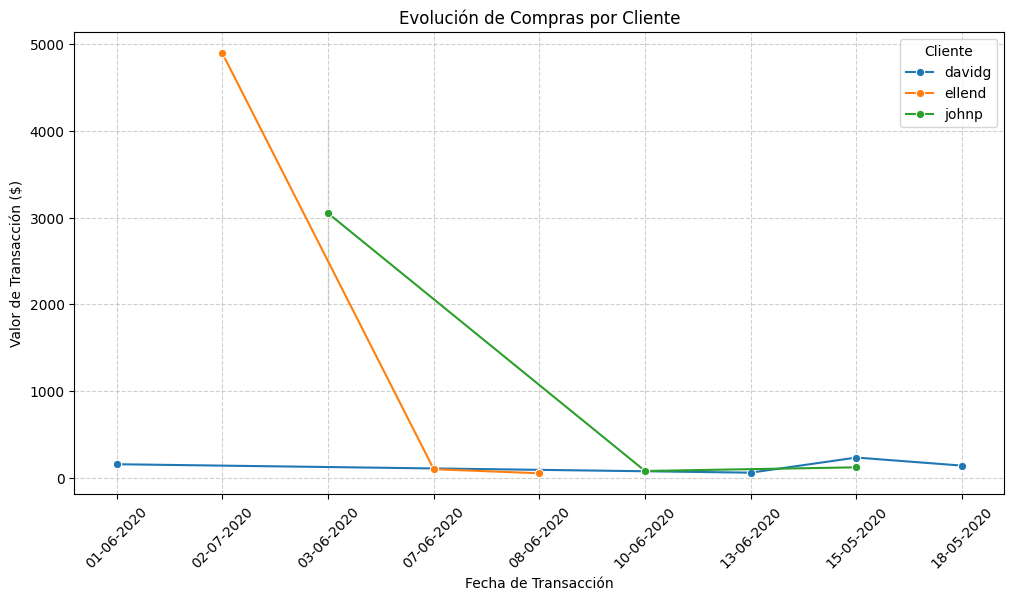

In [76]:
df = df.sort_values('Transaction Date')
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Transaction Date', y='Transaction Value', hue='User ID', marker='o')

plt.title('Evolución de Compras por Cliente')
plt.xlabel('Fecha de Transacción')
plt.ylabel('Valor de Transacción ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cliente')
plt.show()

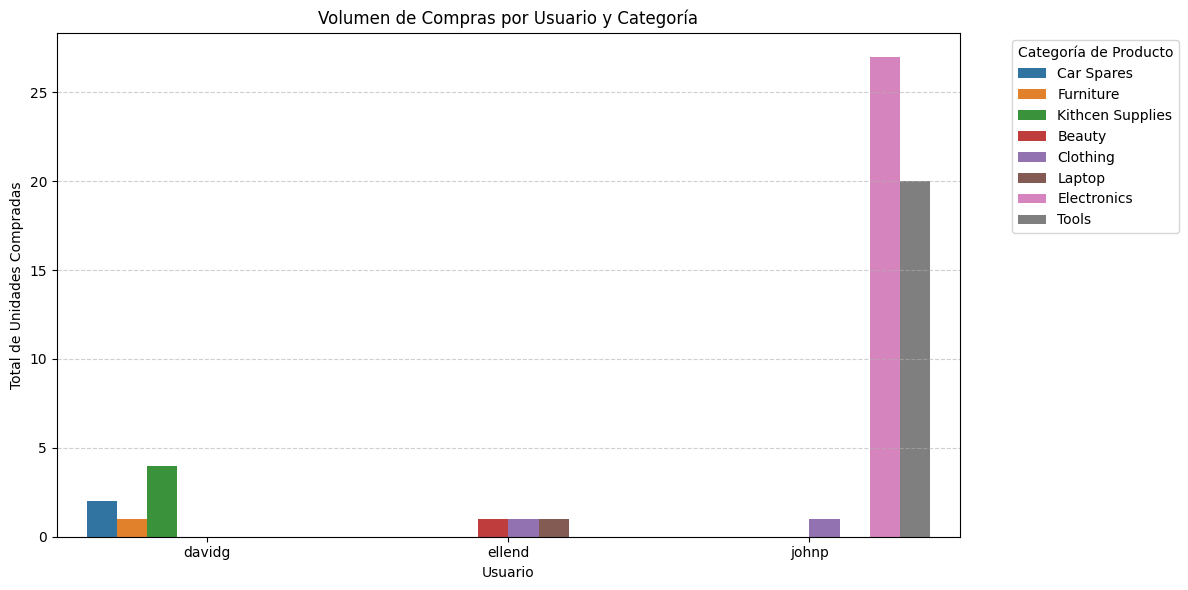

In [77]:
df_counts = df.groupby(['User ID', 'Product Category'])['Units Purchased'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_counts, x='User ID', y='Units Purchased', hue='Product Category')

plt.title('Volumen de Compras por Usuario y Categoría')
plt.xlabel('Usuario')
plt.ylabel('Total de Unidades Compradas')
plt.legend(title='Categoría de Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

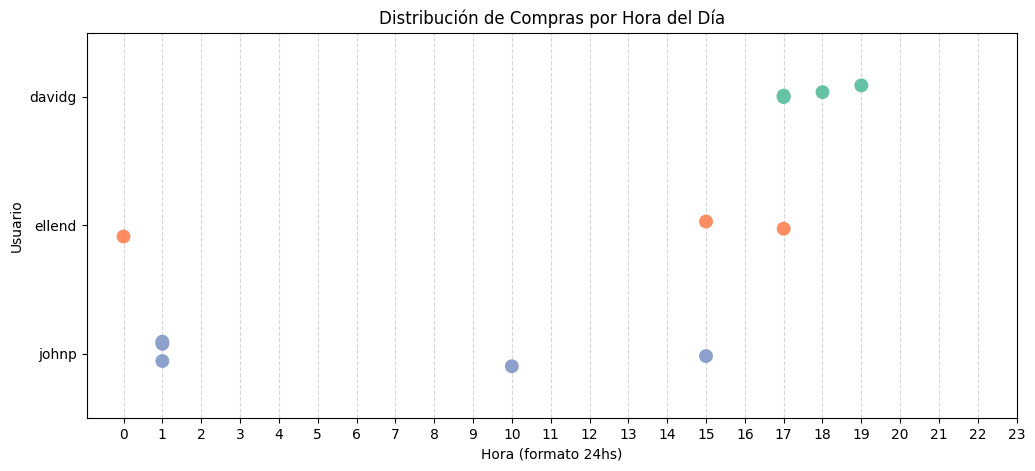

In [80]:
plt.figure(figsize=(12, 5))
sns.stripplot(data=df, x='Hour', y='User ID', hue='User ID', 
              jitter=True, size=10, palette='Set2', legend=False)

plt.title('Distribución de Compras por Hora del Día')
plt.xlabel('Hora (formato 24hs)')
plt.ylabel('Usuario')
plt.xticks(range(0, 24))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [81]:
direcciones = df.groupby('User ID')['Shipping Address'].unique()

for usuario, addr in direcciones.items():
    print(f"Usuario: {usuario}")
    for a in addr:
        print(f"  - {a}")
    print("-" * 20)

Usuario: davidg
  - 90 Robinson Blvd, Alberta, 97602, Canada
--------------------
Usuario: ellend
  - P.O. Box 5401
  - P.O. Box 1322
--------------------
Usuario: johnp
  - In-store
  - P.O. Box 1049
  - 1542, Orchid Lane, WA 98706, US
--------------------


Ellend

C:\Users\Hp\AppData\Local\Temp\ipykernel_25588\2585445320.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ellend, x='Shipping Address', y='Transaction Value', palette='pastel')


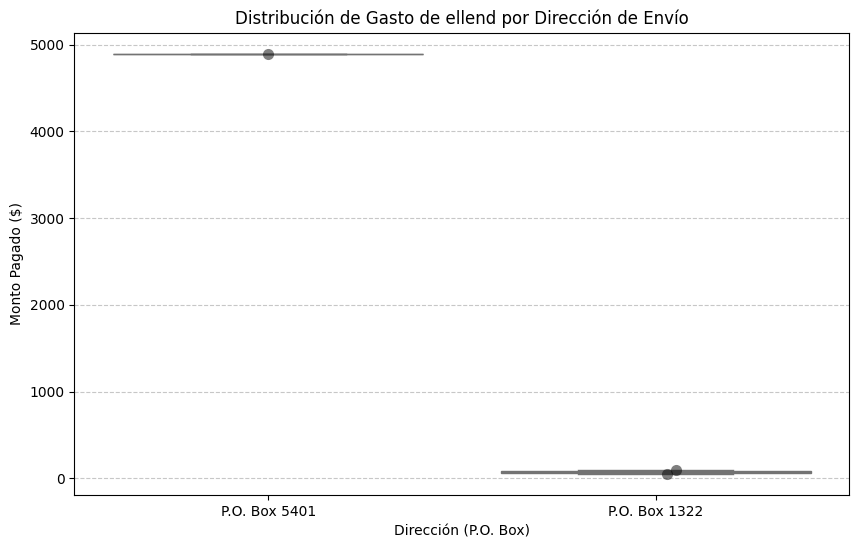

In [82]:
df_ellend = df[df['User ID'] == 'ellend'].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ellend, x='Shipping Address', y='Transaction Value', palette='pastel')
sns.stripplot(data=df_ellend, x='Shipping Address', y='Transaction Value', color='black', size=8, alpha=0.5)

plt.title('Distribución de Gasto de ellend por Dirección de Envío')
plt.xlabel('Dirección (P.O. Box)')
plt.ylabel('Monto Pagado ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Johnp

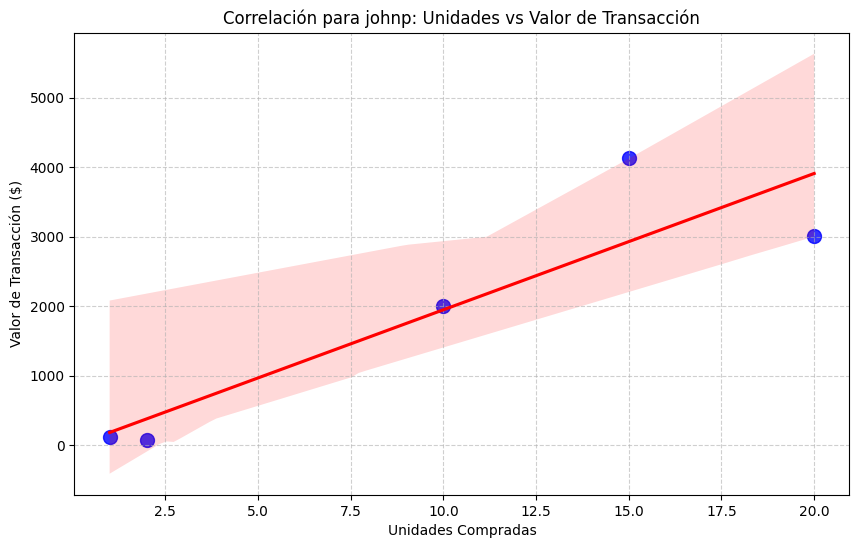

El coeficiente de correlación de Pearson para johnp es: 0.90


In [78]:
df_johnp = df[(df['User ID'] == 'johnp')].dropna(subset=['Transaction Value'])

plt.figure(figsize=(10, 6))
sns.regplot(data=df_johnp, x='Units Purchased', y='Transaction Value', 
            scatter_kws={'s':100, 'color':'blue'}, line_kws={'color':'red'})

plt.title('Correlación para johnp: Unidades vs Valor de Transacción')
plt.xlabel('Unidades Compradas')
plt.ylabel('Valor de Transacción ($)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

correlation = df_johnp['Units Purchased'].corr(df_johnp['Transaction Value'])
print(f"El coeficiente de correlación de Pearson para johnp es: {correlation:.2f}")

In [79]:
resumen_johnp = df_johnp.groupby('IP Address')['Transaction Value'].agg(['sum', 'count', 'mean']).reset_index()
resumen_johnp.columns = ['IP Address', 'Total Gastado', 'Cant. Transacciones', 'Promedio por Compra']

print("Análisis de IPs para johnp:")
display(resumen_johnp)

Análisis de IPs para johnp:


,IP Address,Total Gastado,Cant. Transacciones,Promedio por Compra
0,000.000.00.0,4131.00,1,4131.000
1,1.186.52.7,5020.49,2,2510.245
2,3.56.123.0,200.81,2,100.405


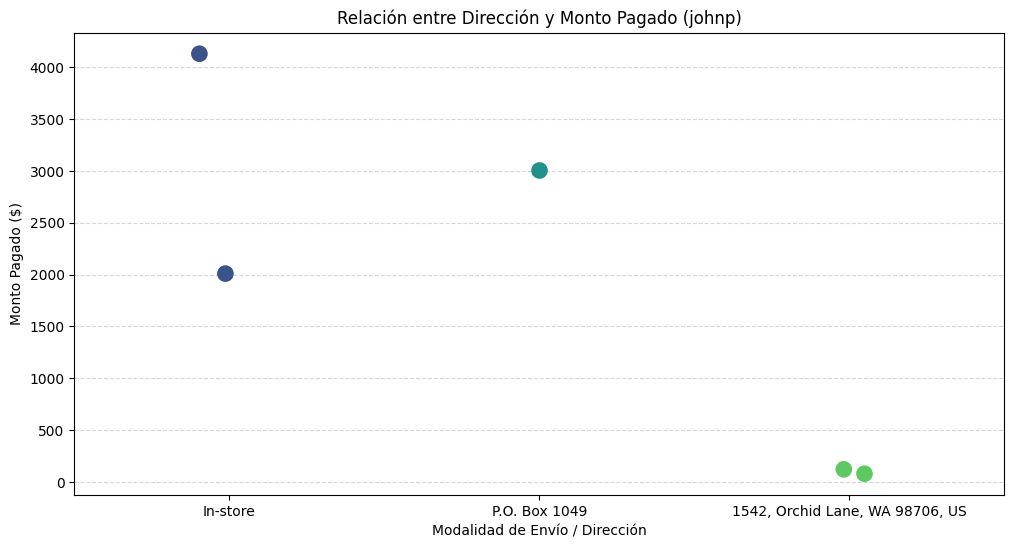

In [83]:
plt.figure(figsize=(12, 6))

# Usamos un stripplot para ver cada compra individual como un punto
sns.stripplot(data=df_johnp, x='Shipping Address', y='Transaction Value', 
              hue='Shipping Address', size=12, jitter=True, palette='viridis', legend=False)

plt.title('Relación entre Dirección y Monto Pagado (johnp)')
plt.xlabel('Modalidad de Envío / Dirección')
plt.ylabel('Monto Pagado ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

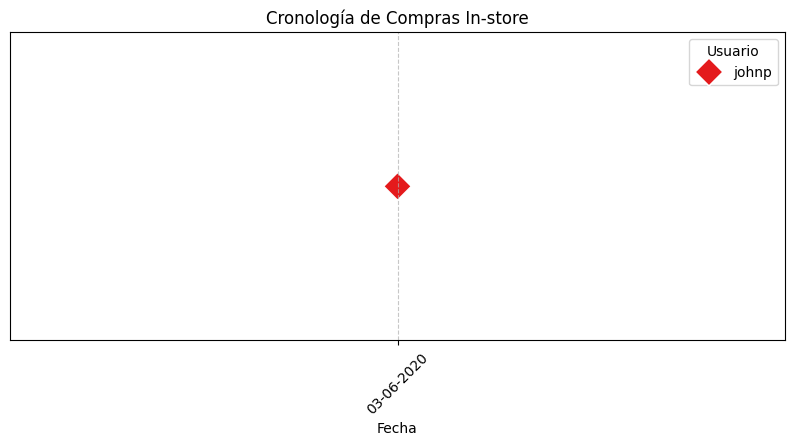

Detalle de compras In-store:


,Transaction Date,Transaction Time,User ID,Transaction Value,Units Purchased
3,03-06-2020,01:11:10,johnp,2009.99,10
4,03-06-2020,01:15:12,johnp,4131.00,15


In [84]:
df_instore = df[df['Shipping Address'] == 'In-store'].copy()

plt.figure(figsize=(10, 4))
sns.scatterplot(data=df_instore, x='Transaction Date', y=[1]*len(df_instore), 
                hue='User ID', s=200, marker='D', palette='Set1')

plt.title('Cronología de Compras In-store')
plt.xlabel('Fecha')
plt.yticks([])
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Usuario')

plt.xticks(df_instore['Transaction Date'].unique(), rotation=45)

plt.show()

print("Detalle de compras In-store:")
display(df_instore[['Transaction Date', 'Transaction Time', 'User ID', 'Transaction Value', 'Units Purchased']])